# SQL Validation & Exploratory Checks  
## The Look E-commerce Retail Case Study

This notebook validates key business logic implemented in SQL and performs light exploratory checks to ensure data quality and segment behavior align with expectations.

The SQL layer serves as the source of truth.  
Python is used only for sanity checks and insight confirmation prior to visualization.


## Load Modeled Data from SQL Exports

The datasets used below are exported outputs from BigQuery after business logic and metric definitions were applied in SQL.


In [3]:
import pandas as pd
from pathlib import Path

DATA = Path("../data_exported_sql")

rfm = pd.read_csv(DATA / "rfm_segments.csv")
kpi = pd.read_excel(DATA / "kpi_monthly.xlsx")
category = pd.read_excel(DATA / "category_health.xlsx")


## Basic Data Sanity Checks

Validate row counts, columns, and missing values before analysis.


In [5]:
rfm.info()
rfm.isna().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48107 entries, 0 to 48106
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   user_id      48107 non-null  int64  
 1   recency      48107 non-null  int64  
 2   frequency    48107 non-null  int64  
 3   monetary     48107 non-null  float64
 4   r_score      48107 non-null  int64  
 5   f_score      48107 non-null  int64  
 6   m_score      48107 non-null  int64  
 7   rfm_score    48107 non-null  int64  
 8   rfm_segment  48107 non-null  object 
dtypes: float64(1), int64(7), object(1)
memory usage: 3.3+ MB


user_id        0
recency        0
frequency      0
monetary       0
r_score        0
f_score        0
m_score        0
rfm_score      0
rfm_segment    0
dtype: int64

## Customer Distribution by RFM Segment

This check ensures that segment sizes follow realistic retail patterns
(e.g., Champions should be a smaller but high-value group).


In [6]:
rfm["rfm_segment"].value_counts()


rfm_segment
At Risk                25840
Potential Loyalists    13262
Loyal Customers         7380
Champions               1625
Name: count, dtype: int64

## Average Value Metrics by Segment

Confirm that:
- Champions have the highest lifetime value
- At Risk customers show lower engagement
- Potential Loyalists sit between low and high value segments


In [8]:
rfm.groupby("rfm_segment")[["monetary", "frequency", "recency"]].mean().round(2)


,monetary,frequency,recency
rfm_segment,,,
At Risk,103.92,1.26,853.37
Champions,350.09,2.73,73.89
Loyal Customers,195.36,2.05,195.87
Potential Loyalists,80.35,1.11,180.67


## Segment Value Comparison

A simple visualization to confirm monetary differences across segments.


<Axes: title={'center': 'Average Lifetime Spend by RFM Segment'}, xlabel='rfm_segment'>

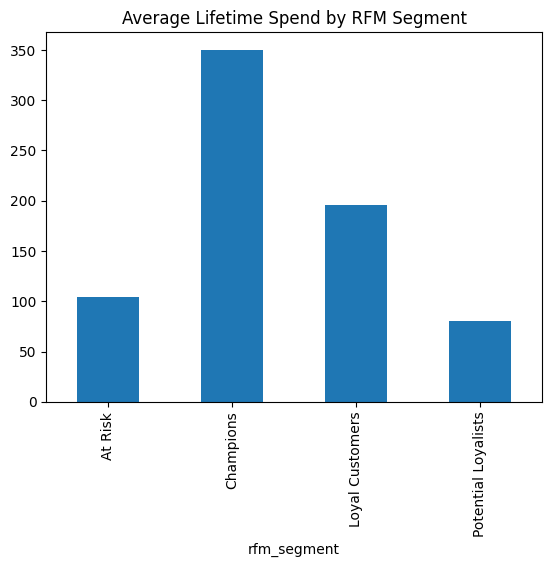

In [9]:
rfm.groupby("rfm_segment")["monetary"].mean().plot(
    kind="bar",
    title="Average Lifetime Spend by RFM Segment"
)


In [10]:
## Key Validation Takeaways

- RFM segmentation logic produces intuitive and business-aligned groups.
- High-value customers are clearly separated from churn-risk segments.
- Results support targeted retention and re-engagement strategies.

These findings were used to design the Tableau dashboards.


SyntaxError: invalid syntax (715332266.py, line 3)